## LLama3.2 Fine-tuning
In this notebook, we will fine-tune Llama 3.2 on the ROCOv2 dataset. Let's get started by installing necessary libraries.

In [1]:
%pip install unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 3.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.6/191.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.1/253.1 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.9/318.9 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.7/766.7 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13

## Configuration and imports

In [ ]:
HF_HOME="/kaggle/working/huggingface" #@param {type:"string"}
HF_TOKEN="<insert your HF token here>" #@param {type:"string"}
WB_TOKEN="<insert your wandb token here>" #@param {type:"string"}

In [2]:
import os
os.environ["HF_HOME"] = HF_HOME
os.environ["HF_TOKEN"] = HF_TOKEN
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from datetime import datetime
import wandb

In [3]:
import os
from unsloth import FastVisionModel
import torch
from datasets import load_dataset
from transformers import TextStreamer
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [4]:
wandb.login(key=WB_TOKEN)
run = wandb.init(project='Fine-tune Llama3.2-11B on RocoV2', job_type="training", anonymous="allow")

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: gimarchetti (gimarchetti-google). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


## Load the model
Note: we are using 4-bit quantization

In [5]:
# 1. Load the model

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Llama-3.2-11B-Vision-Instruct",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
    #device_map = "auto",
)

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules      = True,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

==((====))==  Unsloth 2025.3.9: Fast Mllama patching. Transformers: 4.47.1.
   \\   /|    NVIDIA L4. Num GPUs = 2. Max memory: 22.045 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.9. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Unsloth: Making `model.base_model.model.vision_model.transformer` require gradients


## Load the dataset

In [6]:
from datasets import load_dataset
#ds = load_dataset('mdwiratathya/ROCO-radiology', trust_remote_code=True).remove_columns(['image_id'])
#ds= load_dataset("gaodrew/roco-65k-256px", trust_remote_code=True, split="train").train_test_split(test_size=0.2)
train_ds = load_dataset('eltorio/ROCOv2-radiology', trust_remote_code=True, split="train").remove_columns(['image_id', 'cui'])
test_ds = load_dataset('eltorio/ROCOv2-radiology', trust_remote_code=True, split="test").remove_columns(['image_id', 'cui'])
eval_ds = load_dataset('eltorio/ROCOv2-radiology', trust_remote_code=True, split="validation").remove_columns(['image_id', 'cui'])


Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

In [7]:
train_ds[5]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=800x511>,
 'caption': '5.1 cm x 3.4 cm x 4 cm multiloculated hepatic abscess in the inferior posterior aspect of the right lobe'}

## Preprocess the dataset

**Note**: Using the 'map' function for HF datasets for whatever reason reads the whole base-64-encoded image into each input element and then returns messages in an incorrect format. The following is not efficient, but it is correct.

In [8]:
# 2. Load the dataset
instruction = "You are an expert radiologist. Analyze and diagnose what you see in this image."

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["caption"]} ]
        },
    ]
    return { "messages" : conversation }

In [9]:
import multiprocessing

In [10]:
# for speed and memory limitations, we have to use a small sample. the model won't be very good.
SAMPLE_SIZE = 1500 #@param {"type": "integer"} 

In [11]:
with multiprocessing.Pool(multiprocessing.cpu_count()) as pool:
  train_samples = list(pool.map(convert_to_conversation, train_ds.take(SAMPLE_SIZE)))
  test_samples = list(pool.map(convert_to_conversation, test_ds.take(SAMPLE_SIZE//10)))
  eval_samples = list(pool.map(convert_to_conversation, eval_ds.take(SAMPLE_SIZE//10)))
train_samples[:5]

[{'messages': [{'role': 'user',
    'content': [{'type': 'text',
      'text': 'You are an expert radiographer. Analyze and diagnose what you see in this image.'},
     {'type': 'image',
      'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=682x748>}]},
   {'role': 'assistant',
    'content': [{'type': 'text',
      'text': 'Head CT demonstrating left parotiditis.'}]}]},
 {'messages': [{'role': 'user',
    'content': [{'type': 'text',
      'text': 'You are an expert radiographer. Analyze and diagnose what you see in this image.'},
     {'type': 'image',
      'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=307x224>}]},
   {'role': 'assistant',
    'content': [{'type': 'text',
      'text': 'Acquired renal cysts in end-stage renal failure: 16-year-old girl with Alport syndrome and peritoneal dialysis from the age of 2\xa0years'}]}]},
 {'messages': [{'role': 'user',
    'content': [{'type': 'text',
      'text': 'You are an expert radiographer. Analyze and di

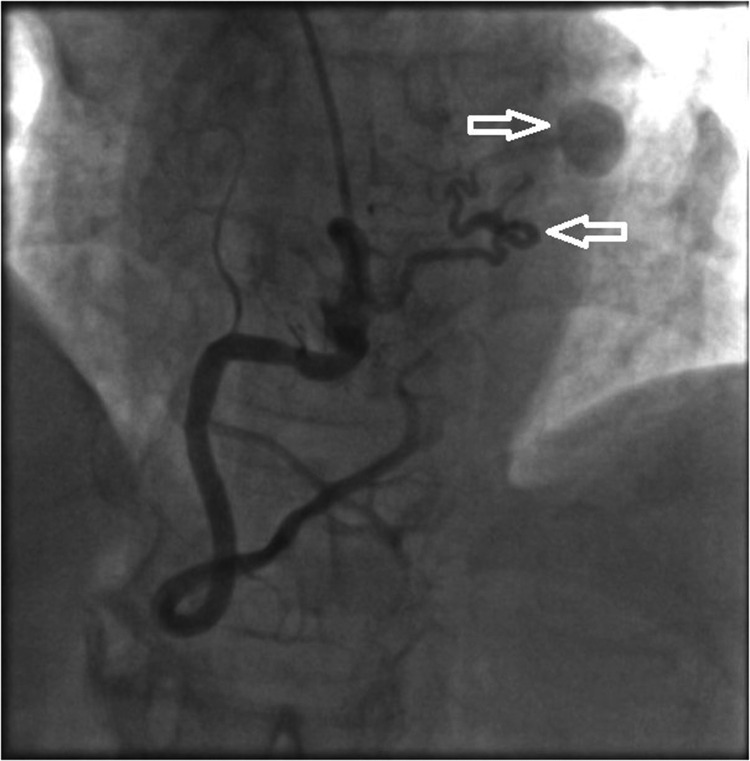

In [17]:
test_ds[456]["image"]

In [18]:
test_ds[456]["caption"]

'Right coronary angiography shows an aberrant vessel, which terminates in the smaller aneurysm, and this is connected to the pulmonary artery.'

## Training
### Before

In [14]:
# 3. Before training

FastVisionModel.for_inference(model)
image = test_ds[456]["image"]
instruction = "You are an expert radiologist. Analyze and diagnose what you see in this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]



In [15]:
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")



In [16]:
print("\nBefore training:\n")

text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)


Before training:

This radiograph appears to be a subtracted angiography image, which involves two steps:

1. Contrast dye is injected into the body, and an X-ray of the region is taken.

2. An X-ray is then taken again, without contrast dye. 

The subtracted radiograph removes the opaque organs and structures like bones, allowing only the less-opaque features such as vessels to show up. 
There is an arterial contrast filling a dilated loop of the duodenum in a patient with Cushing syndrome, an abnormal secretion of the adrenocortical hormone cortisol, which often causes the stomach to become very dilated


### Configure

In [ ]:
# 4. Training

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = train_samples,
    eval_dataset = eval_samples,
    args = SFTConfig(
        num_train_epochs=1,
        auto_find_batch_size = True,
        #per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        #max_steps = 30,
        learning_rate = 2e-4,
        fp16 = not is_bf16_supported(),
        bf16 = is_bf16_supported(),
        logging_steps = 10,
        save_steps = 500,
        eval_strategy="steps",
        eval_steps = 500,
        save_total_limit = 3,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "/kaggle/working/llama32-rocov2",
        report_to = "wandb",
        run_name="llama32-rocov2"+str(datetime.now()),
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        dataset_num_proc = 24,
        max_seq_length = 2048,
    ),
)

In [20]:
gpu_stats = torch.cuda.get_device_properties()
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA L4. Max memory = 22.045 GB.
3.854 GB of memory reserved.


### Train

In [21]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 500 | Num Epochs = 1 | Total steps = 31
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 67,174,400/6,211,872,291 (1.08% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss


In [22]:
wandb.finish()

train/epoch,▁▄██
train/global_step,▁▄██
train/grad_norm,▇▁█
train/learning_rate,█▄▁
total_flos,2618564979937488.0
train/epoch,0.992
train/global_step,31
train/grad_norm,6.43018
train/learning_rate,1e-05
train/loss,nan
train_runtime,2231.4539


In [23]:
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory         /max_memory*100, 3)
lora_percentage = round(used_memory_for_lora/max_memory*100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

2231.4539 seconds used for training.
37.19 minutes used for training.
Peak reserved memory = 8.877 GB.
Peak reserved memory for training = 5.023 GB.
Peak reserved memory % of max memory = 40.268 %.
Peak reserved memory for training % of max memory = 22.785 %.


### After

In [26]:
# 5. After training

print("\nAfter training:\n")
FastVisionModel.for_inference(model)
image = test_ds[456]["image"]
instruction = "You are an expert radiologist. Analyze and diagnose what you see in this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)


After training:

.<|eot_id|>


In [ ]:
test_ds[456]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=750x761>,
 'caption': 'Right coronary angiography shows an aberrant vessel, which terminates in the smaller aneurysm, and this is connected to the pulmonary artery.'}

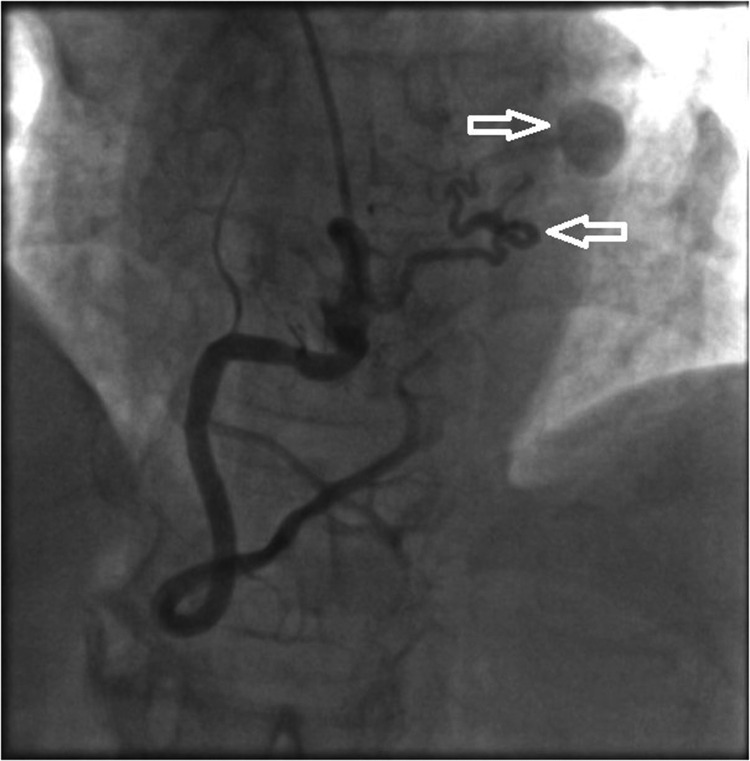

In [ ]:
test_ds[456]["image"]

## Save the model

In [27]:
# 6. Save the model

model.save_pretrained("llama32-rocov2-lora")
tokenizer.save_pretrained("llama32-rocov2-lora")

## OPTIONAL: Push to HF hub
#model.save_pretrained_merged("gimarchetti/Llama-3.2-11B-Vision-RocoV2-4bit", tokenizer,)
#model.push_to_hub_merged("gimarchetti/Llama-3.2-11B-Vision-RocoV2-4bit", tokenizer, save_method = "merged_16bit", token = os.environ.get("HF_TOKEN"))

[]

## Evaluation

In [ ]:
from transformers import AutoModelForVision2Seq, AutoProcessor, LlavaForConditionalGeneration

In [ ]:
model_id = "<insert your HF model id here>" # or use the pretrained "gimarchetti/Llama-3.2-11B-Vision-RocoV2-4bit"
processor_id="meta-llama/Llama-3.2-11B-Vision-Instruct"
processor = AutoProcessor.from_pretrained(processor_id)
model = AutoModelForVision2Seq.from_pretrained(model_id,
                                               torch_dtype=torch.bfloat16,
                                               #_attn_implementation="flash_attention_2",
                                               device_map="balanced")

preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.8k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/5.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

...

model-00004-of-00005.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00005-of-00005.safetensors:   0%|          | 0.00/1.47G [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/accelerate/utils/modeling.py:1390: UserWarning: Current model requires 128 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

In [28]:
model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MllamaForConditionalGeneration(
      (vision_model): MllamaVisionModel(
        (patch_embedding): Conv2d(3, 1280, kernel_size=(14, 14), stride=(14, 14), padding=valid, bias=False)
        (gated_positional_embedding): MllamaPrecomputedPositionEmbedding(
          (tile_embedding): Embedding(9, 8197120)
        )
        (pre_tile_positional_embedding): MllamaPrecomputedAspectRatioEmbedding(
          (embedding): Embedding(9, 5120)
        )
        (post_tile_positional_embedding): MllamaPrecomputedAspectRatioEmbedding(
          (embedding): Embedding(9, 5120)
        )
        (layernorm_pre): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (layernorm_post): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (transformer): MllamaVisionEncoder(
          (layers): ModuleList(
            (0-12): 13 x MllamaVisionEncoderLayer(
              (self_attn): MllamaVisionSdpaAttention(
               

In [31]:
example = test_ds[752]
example

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=750x855>,
 'caption': 'Computerized tomography of the neck showing pneumomediastinum with subcutaneous gas throughout the neck soft tissue (red arrows)'}

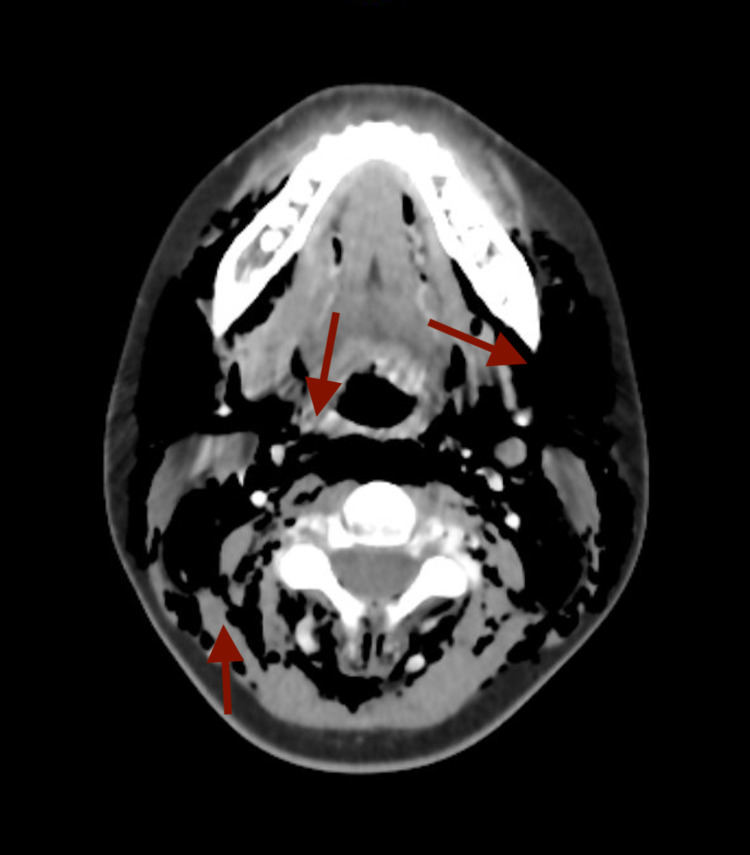

In [32]:
example["image"]

In [ ]:
messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": "You are an expert radiologist. Analyze and diagnose what you see in this image. "}
    ]}
]
image=example["image"].convert("RGB")#.resize((256, 256))
input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt"
).to(model.device)

output = model.generate(**inputs, max_new_tokens=128)
print(processor.decode(output[0]))

## Evaluate on subset

## Evaluate on subset

In [ ]:
example

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 'text': 'transabdominal ultrasounds scan showing loss of the retroplacental myometrium and interrupted plane between bladder and placenta .'}

In [ ]:
def generate_caption(example, max_new_tokens=32, temperature=0.5, top_p=0.9, top_k=40):
  image = example["image"].convert("RGB")#.resize((256, 256))
  messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": "You are an expert radiologist. Describe accurately what you see in this image. "}
    ]}
  ]
  input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
  inputs=processor(
      image,
      input_text,
      add_special_tokens=False,
      return_tensors="pt",
      #padding="longest",
    ).to("cuda")
  generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, temperature=temperature, top_p=top_p, top_k=top_k, do_sample=True)
  #print(generated_ids
  generated_texts= processor.decode(generated_ids[0], skip_special_tokens=True).split("\n")[-1]
  return generated_texts


In [ ]:
generate_caption(example, temperature=0.4, top_p=0.5, top_k=10)

'ultrasonography of the bladder and the placenta. the bladder is dilated and the placenta is thickened.'

In [ ]:
SAMPLE_SIZE = 5 #@param

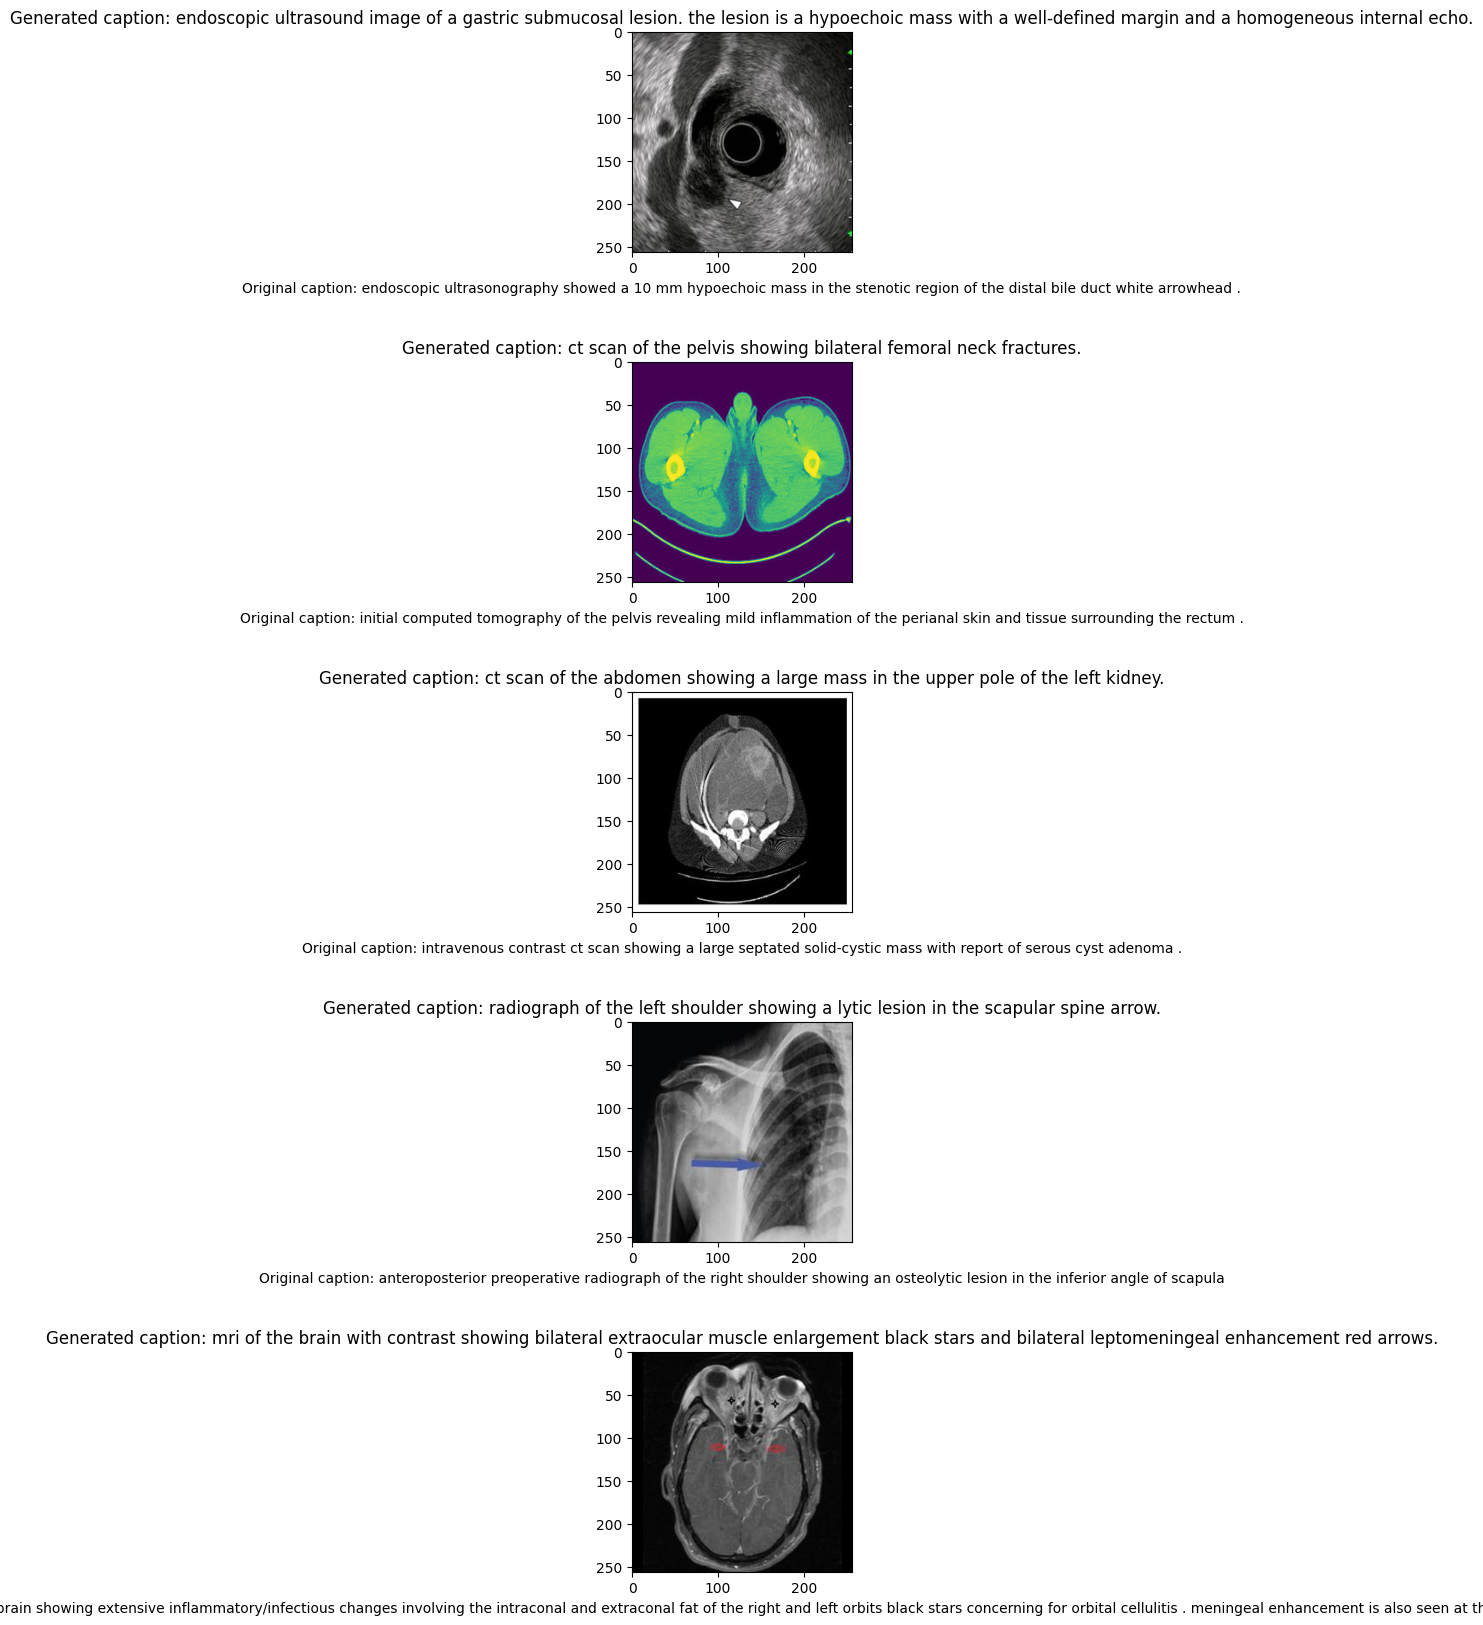

In [ ]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(20, 20 ))# 5*SAMPLE_SIZE))

# prepare image for the model
for i, example in enumerate(test_ds.shuffle().take(SAMPLE_SIZE)):
  generated_caption = generate_caption(example, max_new_tokens=32, temperature=0.4, top_p=0.5, top_k=10 )
  fig.add_subplot(SAMPLE_SIZE, 1, i+1)
  plt.imshow(example["image"])
  plt.subplots_adjust(hspace=0.1*SAMPLE_SIZE)  # Adjust vertical spacing
  #plt.axis("off")
  plt.title(f"Generated caption: {generated_caption}")
  plt.xlabel(f"Original caption: {example['text']}")

In [ ]:
model.save_pretrained("/kaggle/working/llama32-rocov2")